# 08 – Evaluation

**Project:** Diabetes Prediction ML  
**Seminar:** Advanced Applied Data Science – Goethe University Frankfurt  
**Dataset:** CDC BRFSS 2015 – Diabetes Health Indicators (UCI #891)  
**Target:** `Diabetes_binary` (0 = No Diabetes, 1 = Prediabetes/Diabetes)  
**CRISP-DM phase:** 5 – Evaluation · Final, unbiased test-set assessment

---

## 1. Purpose

This is the final notebook. NB07 fixed everything that involves a *choice*; NB08 spends the one resource it has not yet touched — the **held-out test set** — to produce a single, unbiased estimate of how the model generalises, and persists a deployable model for hand-off.

**The cardinal rule of this notebook.** The test set is **read-only** and used **once**. NB08 makes **no new modelling decisions**: no model selection, no threshold tuning, no calibration decision, no feature changes are made on the basis of test results. All of those were settled in NB05–NB07 on cross-validation / out-of-fold (OOF) evidence. Everything below is **reporting and diagnostics** — and although several sections (subgroups, calibration, SHAP, false-positive profiling) read the test set, none of them feeds back into any choice.

**What is frozen, and where it comes from (`outputs/nb07/nb07_finalists.json`):**

- **Final model (primary):** the **tuned LightGBM** on `headline_pool` (raw 21 + `BMI²`), `imbalance = none`. Selected in NB07 on the best CV PR-AUC among the tuned finalists (≈ 0.4371, > 1 SE above the others). *(Note: `BMI²` is inert for the tree — a monotone transform of `BMI` that gradient-boosted trees reconstruct internally; it is carried only because the finalists share one feature set, where it is the single real gain for the linear companion. It is harmless, not helpful, for LightGBM.)*
- **Interpretable companion:** **LogReg-L2** — not a performance pick (~3 SE below); carried for a transparent, coefficient-level read-out of risk drivers.
- **Pre-registered secondary comparison:** the **MLP + LightGBM stack** — declared in NB07 as *not promoted* (it did not clear the 1·SE bar over tuned LightGBM on OOF). Evaluated here only so the pre-registered comparison is reported on test; it does **not** become the deployed model regardless of its test number.
- **Operating threshold:** **≈ 0.138**, the largest OOF threshold that still keeps recall ≥ 0.80. A deliberate recall-floor *policy* (screening: a missed at-risk person costs more than a false alarm), not an intrinsic optimum.
- **Calibration:** **none** — decided in NB07 on OOF reliability/Brier. Reported here as a diagnostic only.

**Threshold policy.** The operating threshold is the **largest OOF threshold that still keeps recall ≥ 0.80** (a recall floor) — the screening policy stated in NB01 §6, where a missed at-risk person is costlier than a false alarm. NB08 applies this **frozen** threshold (≈ 0.138) as-is; because the final model is *refit on the full training set* (the OOF folds each saw only 4/5 of the data), the realised test recall may differ slightly from the OOF 0.80. That drift is part of the honest generalisation read, not something to correct.

## 2. Setup

In [1]:
import warnings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

import json, time, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             precision_recall_curve, roc_curve, precision_score,
                             recall_score, f1_score, fbeta_score, confusion_matrix,
                             matthews_corrcoef, balanced_accuracy_score)
from sklearn.calibration import calibration_curve

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# repo root + shared utilities (identical pattern to NB03-07)
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "notebooks").is_dir())
DATA_DIR    = PROJECT_ROOT / "data" / "processed"
NB07_DIR    = PROJECT_ROOT / "outputs" / "nb07"
OUTPUT_DIR  = PROJECT_ROOT / "outputs" / "nb08"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = PROJECT_ROOT / "outputs" / "results.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import log_result            # shared ledger writer
from src.features import build_candidates    # row-wise, leakage-free feature builder (NB05)

# defensive ledger wrapper: log only fields the installed log_result accepts (as in NB06/07)
import inspect as _inspect
_LOG_KEYS = set(_inspect.signature(log_result).parameters)
_LOG_KWARGS = any(p.kind == p.VAR_KEYWORD for p in _inspect.signature(log_result).parameters.values())
def safe_log_result(path, **kw):
    if _LOG_KWARGS:
        return log_result(path, **kw)
    return log_result(path, **{k: v for k, v in kw.items() if k in _LOG_KEYS})

import sklearn, lightgbm
print(f"sklearn {sklearn.__version__} | lightgbm {lightgbm.__version__}")
print("output dir:", OUTPUT_DIR)

sklearn 1.8.0 | lightgbm 4.6.0
output dir: c:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\nb08


In [2]:
# ---------------------------------------------------------------------
# NB08 configuration. NB08 makes NO new modelling decisions; these flags
# only toggle OPTIONAL diagnostic analyses and set their compute budgets.
# The core evaluation (sections 5-6) always runs.
# ---------------------------------------------------------------------
BOOT_N           = 1000   # bootstrap replicates for test-metric CIs (lower to ~300 to save time)
RUN_STACK        = True    # pre-registered secondary comparison (refits MLP -> slowest cell)
RUN_SHAP         = True    # SHAP interpretability (needs the `shap` package, listed in requirements)
RUN_PU           = False   # PU-inspired sensitivity illustration (OFF by default; see 11.2 - assumptions not met)
RUN_GROUP_THRESH = True    # illustrative per-subgroup thresholds (DERIVED ON TRAIN OOF only)
SHAP_SAMPLE      = 4000    # rows sampled for the SHAP summary plot

print(f"BOOT_N={BOOT_N} | RUN_STACK={RUN_STACK} | RUN_SHAP={RUN_SHAP} | "
      f"RUN_PU={RUN_PU} | RUN_GROUP_THRESH={RUN_GROUP_THRESH}")

BOOT_N=1000 | RUN_STACK=True | RUN_SHAP=True | RUN_PU=False | RUN_GROUP_THRESH=True


## 3. Load the frozen decisions from NB07

Everything loaded here is a decision **already made** — read it, do not re-open it. The primary model, the companion, the operating threshold, and the calibration decision all come straight from `nb07_finalists.json`.

In [3]:
# canonical features + seed (single source of truth from NB03)
with open(DATA_DIR / "feature_meta.json") as f:
    feature_meta = json.load(f)
ALL_FEATURES = feature_meta["all_features"]
SEED = feature_meta["seed"]
np.random.seed(SEED)

# NB05 feature decision
with open(DATA_DIR / "feature_sets_nb05.json") as f:
    HEADLINE_POOL = json.load(f)["headline_pool"]            # raw21 + BMI_squared (22 cols)

# NB07 hand-off: tuned params, threshold, calibration decision, stack recipe
with open(NB07_DIR / "nb07_finalists.json") as f:
    nb07 = json.load(f)

# tuned out-of-fold predictions: loaded ONCE here, reused by calibration / stack / group-threshold cells
oof = pd.read_parquet(NB07_DIR / "nb07_tuned_oof.parquet")

PRIMARY_NAME   = nb07["final_for_nb08"]["primary"]                       # 'LightGBM'
COMPANION_NAME = nb07["final_for_nb08"]["companion"]                     # 'LogReg-L2'
THRESHOLD      = float(nb07["final_for_nb08"]["operating_threshold"])    # ~0.1379 (recall floor)
RECALL_TARGET  = 0.80   # mirrors NB07's policy; used only for the illustrative per-group thresholds in 9
FBETA          = 2.0    # F2 is reported as a recall-weighted diagnostic only; it does NOT select the threshold
OOF_METRICS    = nb07["final_for_nb08"]["operating_metrics"]            # OOF reference (mildly optimistic)

print("Frozen from NB07 (NOT re-decided in NB08):")
print(f"  primary model       : {PRIMARY_NAME}")
print(f"  interpretable comp. : {COMPANION_NAME}")
print(f"  operating threshold : {THRESHOLD:.4f}   (largest OOF threshold with recall >= {RECALL_TARGET})")
print(f"  calibration         : none (decided in NB07 on OOF evidence)")
print(f"  feature set         : {nb07['feature_set']}  |  imbalance: {nb07['imbalance']}")
print(f"  OOF reference PR-AUC: {OOF_METRICS['PR_AUC']}   <- the number NB08 tests for generalisation")

Frozen from NB07 (NOT re-decided in NB08):
  primary model       : LightGBM
  interpretable comp. : LogReg-L2
  operating threshold : 0.1379   (largest OOF threshold with recall >= 0.8)
  calibration         : none (decided in NB07 on OOF evidence)
  feature set         : headline_pool  |  imbalance: none
  OOF reference PR-AUC: 0.4364   <- the number NB08 tests for generalisation


In [4]:
# Reconstruct each finalist EXACTLY as frozen in NB07 (estimator_defaults + tuned params).
#
# Defensive fallback: the CURRENT NB07 persists an 'estimator_defaults' block, but if an
# OLDER nb07_finalists.json is on disk it might not. We merge a hard-coded fallback with
# whatever the JSON provides (the JSON wins on conflicts), so NB08 reconstructs cleanly
# either way and never KeyErrors on a stale hand-off.
ESTIMATOR_DEFAULTS_FALLBACK = {
    "LightGBM": {"verbose": -1, "n_jobs": -1, "random_state": SEED, "subsample_freq": 1},
    "MLP":      {"max_iter": 300, "early_stopping": True, "n_iter_no_change": 10,
                 "validation_fraction": 0.1, "random_state": SEED},
    "LogReg-L2": {"penalty": "l2", "max_iter": 2000, "random_state": SEED},
}

def _defaults(name):
    saved = nb07.get("estimator_defaults", {}).get(name, {})
    return {**ESTIMATOR_DEFAULTS_FALLBACK.get(name, {}), **saved}   # saved overrides fallback

def make_pipe(estimator, scale):
    steps = ([("scale", StandardScaler())] if scale else []) + [("model", estimator)]
    return Pipeline(steps)

def build_estimator(name):
    defaults = _defaults(name)
    params   = dict(nb07["tuned"][name]["params"])
    if name == "LightGBM":
        return make_pipe(LGBMClassifier(**defaults, **params), scale=False)
    if name == "LogReg-L2":
        return make_pipe(LogisticRegression(**defaults, **params), scale=True)
    if name == "MLP":
        if isinstance(params.get("hidden_layer_sizes"), list):
            params["hidden_layer_sizes"] = tuple(params["hidden_layer_sizes"])
        return make_pipe(MLPClassifier(**defaults, **params), scale=True)
    raise ValueError(f"unknown finalist: {name}")

if "estimator_defaults" not in nb07:
    print("WARNING: 'estimator_defaults' missing from nb07_finalists.json -> using fallback defaults.")
print("Estimator factory ready for:", list(nb07["tuned"].keys()))

Estimator factory ready for: ['LogReg-L2', 'LightGBM', 'MLP']


## 4. Load training data and the frozen test set (first and only time)

The training set is loaded to **refit** the final model on the full training data. The test set is read here for the **first time in the entire project** — every earlier notebook asserted it must not be loaded. Engineered features on the test set are built with the same row-wise, deterministic `build_candidates` transform as NB05 (no fitted statistic, fixed clinical bounds), so applying it to the test rows introduces no leakage.

In [5]:
# --- training data (to REFIT the final model on the full train set) ---
X_train_raw  = pd.read_parquet(DATA_DIR / "X_train.parquet")[ALL_FEATURES]
X_train_cand = pd.read_parquet(DATA_DIR / "X_train_candidates.parquet")
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")
X_train_pool = X_train_cand[HEADLINE_POOL]

# --- THE FROZEN TEST SET: loaded here for the FIRST and ONLY time ---
X_test_raw = pd.read_parquet(DATA_DIR / "X_test.parquet")[ALL_FEATURES]
y_test     = pd.read_parquet(DATA_DIR / "y_test.parquet").squeeze("columns")

# leakage-free, row-wise engineered features on test (identical transform to NB05)
X_test_cand = build_candidates(X_test_raw)
X_test_pool = X_test_cand[HEADLINE_POOL]

# --- guards: this must be the real, disjoint NB03 split ---
assert list(X_test_pool.columns) == list(X_train_pool.columns), "feature columns drift train vs test"
assert X_test_pool.isna().sum().sum() == 0, "NaNs in test feature matrix"
assert len(set(X_train_raw.index) & set(X_test_raw.index)) == 0, "train/test row index overlap!"
assert abs(y_test.mean() - y_train.mean()) < 0.005, "test prevalence drifted from train"

prevalence_test = float(y_test.mean())
yte = y_test.values
print(f"train: {X_train_pool.shape} | test: {X_test_pool.shape}")
print(f"prevalence  train {y_train.mean():.4f} | test {prevalence_test:.4f} "
      f"(no-skill PR-AUC floor = {prevalence_test:.4f})")
print(f"test positives: {int(y_test.sum()):,} of {len(y_test):,}")

train: (202943, 22) | test: (50737, 22)
prevalence  train 0.1393 | test 0.1393 (no-skill PR-AUC floor = 0.1393)
test positives: 7,070 of 50,737


## 5. Refit the final model on the full training set, score the test set once

NB07 chose the hyperparameters via cross-validation; the deployed model is the same estimator **refit on all training data** with those frozen parameters, then evaluated a single time on the test set.

In [6]:
# primary (deployed) model
primary_pipe = build_estimator(PRIMARY_NAME)
t0 = time.time(); primary_pipe.fit(X_train_pool, y_train)
p_test = primary_pipe.predict_proba(X_test_pool)[:, 1]
print(f"{PRIMARY_NAME} refit on {len(y_train):,} rows and scored on test ({time.time()-t0:.1f}s)")

# interpretable companion (refit too; for interpretation + as a pre-registered comparison)
companion_pipe = build_estimator(COMPANION_NAME)
companion_pipe.fit(X_train_pool, y_train)
p_test_comp = companion_pipe.predict_proba(X_test_pool)[:, 1]
print(f"{COMPANION_NAME} refit (interpretable companion)")

LightGBM refit on 202,943 rows and scored on test (6.2s)
LogReg-L2 refit (interpretable companion)


### 5.1 The unbiased generalisation estimate

PR-AUC is the headline number (primary metric throughout the project); ROC-AUC and Brier are diagnostics. The 95 % CIs use a **group-aware (cluster) bootstrap**: whole *profiles* are resampled, not individual rows, so the ~14 % duplicate profiles in the test set do not make the interval falsely tight.

In [7]:
# group-aware bootstrap: resample whole PROFILES (the NB03 grouping unit)
test_groups = pd.util.hash_pandas_object(X_test_raw, index=False).values
_g_codes, _ = pd.factorize(test_groups)
_rows_of = [np.where(_g_codes == c)[0] for c in range(_g_codes.max() + 1)]

def boot_ci(y, p, fn, n_boot=BOOT_N, alpha=0.05, seed=SEED):
    rng = np.random.RandomState(seed)
    n_groups = len(_rows_of)
    y = np.asarray(y); p = np.asarray(p)
    stats = np.empty(n_boot)
    for b in range(n_boot):
        pick = rng.randint(0, n_groups, size=n_groups)
        rows = np.concatenate([_rows_of[c] for c in pick])
        stats[b] = fn(y[rows], p[rows])
    lo, hi = np.percentile(stats, [100*alpha/2, 100*(1-alpha/2)])
    return float(lo), float(hi)

pr_test    = average_precision_score(yte, p_test)
roc_test   = roc_auc_score(yte, p_test)
brier_test = brier_score_loss(yte, p_test)
pr_lo, pr_hi   = boot_ci(yte, p_test, average_precision_score)
roc_lo, roc_hi = boot_ci(yte, p_test, roc_auc_score)

print(f"=== UNBIASED TEST PERFORMANCE  ({PRIMARY_NAME}, refit on full train) ===")
print(f"  PR-AUC  : {pr_test:.4f}   95% CI [{pr_lo:.4f}, {pr_hi:.4f}]")
print(f"            OOF ref {OOF_METRICS['PR_AUC']} | no-skill floor {prevalence_test:.4f} "
      f"| lift x{pr_test/prevalence_test:.2f}")
print(f"  ROC-AUC : {roc_test:.4f}   95% CI [{roc_lo:.4f}, {roc_hi:.4f}]   (OOF ref {OOF_METRICS['ROC_AUC']})")
print(f"  Brier   : {brier_test:.4f}   (OOF ref {OOF_METRICS['Brier']})")
print(f"  OOF -> test gap (PR-AUC): {pr_test - OOF_METRICS['PR_AUC']:+.4f}")

=== UNBIASED TEST PERFORMANCE  (LightGBM, refit on full train) ===
  PR-AUC  : 0.4330   95% CI [0.4217, 0.4458]
            OOF ref 0.4364 | no-skill floor 0.1393 | lift x3.11
  ROC-AUC : 0.8288   95% CI [0.8238, 0.8336]   (OOF ref 0.8313)
  Brier   : 0.0968   (OOF ref 0.0963)
  OOF -> test gap (PR-AUC): -0.0034


#### Interpretation — the headline number

The single unbiased estimate is **test PR-AUC = 0.433** (95 % CI [0.422, 0.446]), against a no-skill floor of 0.139 — about **3.1× better than chance** in the precision/recall regime that matters under imbalance. Crucially, the NB07 OOF reference (0.436) lies *inside* this test CI (OOF→test gap −0.003), so the cross-validation estimate generalised and the winner's curse from CV selection was negligible. ROC-AUC is 0.829 (OOF 0.831) and Brier 0.097 (OOF 0.096) — both essentially unchanged from CV, confirming the held-out result is not an optimistic artefact.

## 6. Operating point — applying the frozen threshold

PR-AUC measures ranking; deployment needs a decision. We apply the **frozen** recall-floor threshold (≈ 0.138, the largest OOF threshold with recall ≥ 0.80) — chosen on OOF in NB07, **not** re-tuned here — and report the full clinical metric set with the confusion matrix. Recall and precision get their own group-aware bootstrap CIs.

In [8]:
pred = (p_test >= THRESHOLD).astype(int)
tn, fp, fn_, tp = confusion_matrix(yte, pred, labels=[0, 1]).ravel()

def _recall(y, p): return recall_score(y, (p >= THRESHOLD).astype(int), zero_division=0)
def _prec(y, p):   return precision_score(y, (p >= THRESHOLD).astype(int), zero_division=0)
rec_lo, rec_hi = boot_ci(yte, p_test, _recall)
prc_lo, prc_hi = boot_ci(yte, p_test, _prec)

at_thr = {
    "threshold": round(THRESHOLD, 4),
    "precision": round(precision_score(yte, pred, zero_division=0), 4),
    "recall_sensitivity": round(recall_score(yte, pred, zero_division=0), 4),
    "specificity": round(tn / (tn + fp), 4),
    "F1": round(f1_score(yte, pred, zero_division=0), 4),
    f"F{int(FBETA)}": round(fbeta_score(yte, pred, beta=FBETA, zero_division=0), 4),
    "balanced_acc": round(balanced_accuracy_score(yte, pred), 4),
    "MCC": round(matthews_corrcoef(yte, pred), 4),
}
print(json.dumps(at_thr, indent=2))
print(f"recall    95% CI [{rec_lo:.4f}, {rec_hi:.4f}]   (OOF recall    {OOF_METRICS['recall_sensitivity']})")
print(f"precision 95% CI [{prc_lo:.4f}, {prc_hi:.4f}]   (OOF precision {OOF_METRICS['precision']})")
print(f"confusion @ {THRESHOLD:.3f}:  TN={tn}  FP={fp}  FN={fn_}  TP={tp}")

{
  "threshold": 0.1379,
  "precision": 0.3057,
  "recall_sensitivity": 0.7894,
  "specificity": 0.7097,
  "F1": 0.4407,
  "F2": 0.5996,
  "balanced_acc": 0.7496,
  "MCC": 0.3601
}
recall    95% CI [0.7798, 0.7987]   (OOF recall    0.8)
precision 95% CI [0.2990, 0.3121]   (OOF precision 0.3078)
confusion @ 0.138:  TN=30992  FP=12675  FN=1489  TP=5581


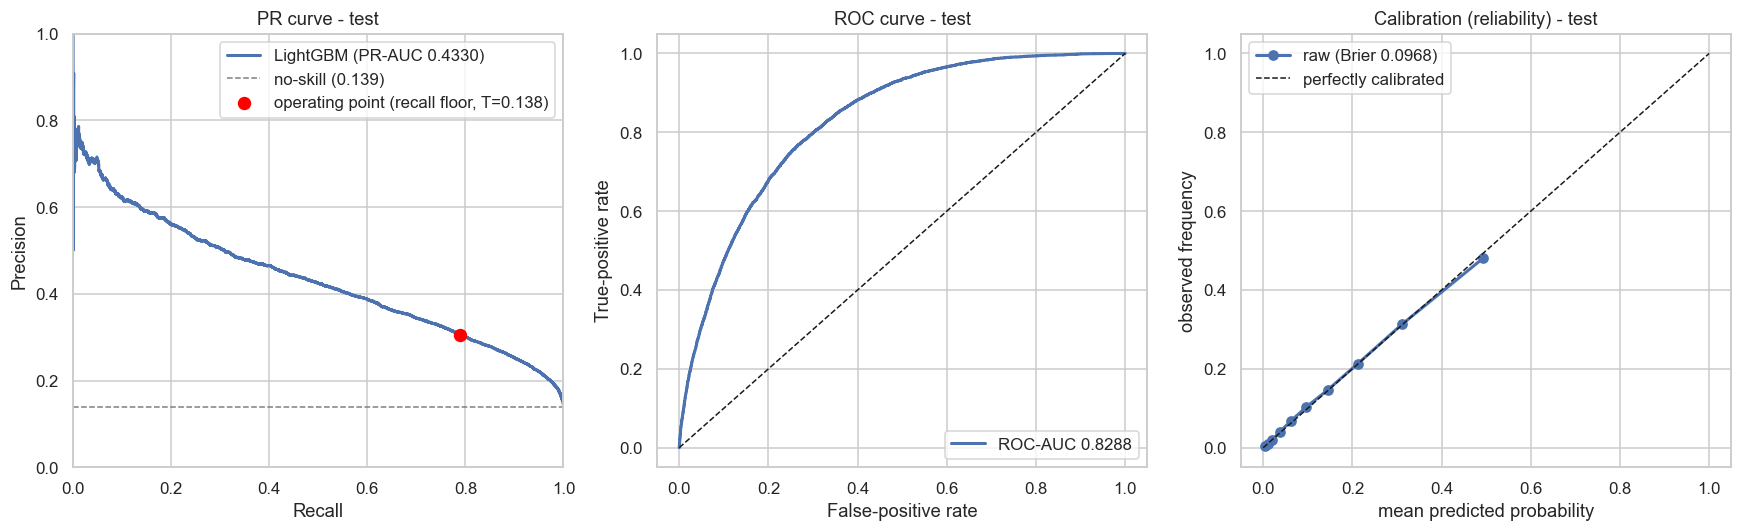

In [9]:
# PR (with operating point) + ROC + calibration, all on the TEST set
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

p_, r_, _ = precision_recall_curve(yte, p_test)
ax[0].plot(r_, p_, lw=2, label=f"{PRIMARY_NAME} (PR-AUC {pr_test:.4f})")
ax[0].axhline(prevalence_test, ls="--", c="grey", lw=1, label=f"no-skill ({prevalence_test:.3f})")
ax[0].scatter([at_thr["recall_sensitivity"]], [at_thr["precision"]], c="red", zorder=5, s=60,
              label=f"operating point (recall floor, T={THRESHOLD:.3f})")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision"); ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].set_title("PR curve - test"); ax[0].legend(loc="upper right")

fpr, tpr, _ = roc_curve(yte, p_test)
ax[1].plot(fpr, tpr, lw=2, label=f"ROC-AUC {roc_test:.4f}")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("False-positive rate"); ax[1].set_ylabel("True-positive rate")
ax[1].set_title("ROC curve - test"); ax[1].legend(loc="lower right")

frac_pos, mean_pred = calibration_curve(yte, p_test, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, frac_pos, "o-", lw=2, label=f"raw (Brier {brier_test:.4f})")
ax[2].plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
ax[2].set_xlabel("mean predicted probability"); ax[2].set_ylabel("observed frequency")
ax[2].set_title("Calibration (reliability) - test"); ax[2].legend(loc="upper left")

plt.tight_layout(); plt.savefig(OUTPUT_DIR / "nb08_final_diagnostics.png", bbox_inches="tight")
plt.show()

#### Interpretation — the operating point

At the frozen threshold (0.1379) the model flags **78.9 % of true cases** (recall) at **precision 0.306**, with specificity 0.710 and balanced accuracy 0.750. The recall-floor policy was satisfied on OOF (recall = 0.80) but transferred to the refit test model with a small shortfall: **test recall = 0.7894, with a 95 % CI of [0.780, 0.799] lying just below the 0.80 target.** We report this as **threshold-transfer drift** — the threshold was fixed on OOF folds while the final model was refit on the full training set — and we do **not** retune on the test set, which would be leakage. NB01 success criterion 2 is therefore a **narrow miss, flagged for discussion**, not a pass: the deployed policy catches ~79 % of cases on truly unseen data.

## 7. Calibration — diagnostic only (decision frozen as "none")

NB07 decided **not** to recalibrate, on OOF evidence. The raw reliability curve and Brier above are the unbiased read. As an **illustration only**, the cell below shows what isotonic recalibration *would* do — with the isotonic map fit on **train OOF** (`nb07_tuned_oof.parquet`), never on the test set. On this run isotonic recalibration does **not** improve Brier (0.0968 → 0.0969) and actually **lowers PR-AUC** (0.4330 → 0.4276), because mapping many scores onto the same value introduces ranking ties. This empirically supports the NB07 decision to keep the raw probabilities without post-hoc calibration.

In [10]:
iso = IsotonicRegression(out_of_bounds="clip").fit(oof["oof_lgbm"].values, oof["y_true"].values)
p_test_iso = iso.transform(p_test)
brier_iso = brier_score_loss(yte, p_test_iso)

print(f"Brier raw      : {brier_test:.4f}")
print(f"Brier isotonic : {brier_iso:.4f}   (ILLUSTRATION; map fit on TRAIN OOF, not test)")
print(f"PR-AUC raw {average_precision_score(yte, p_test):.4f} vs isotonic "
      f"{average_precision_score(yte, p_test_iso):.4f}  "
      f"(isotonic does not improve Brier and lowers PR-AUC via ties -> keep raw, per NB07)")

Brier raw      : 0.0968
Brier isotonic : 0.0969   (ILLUSTRATION; map fit on TRAIN OOF, not test)
PR-AUC raw 0.4330 vs isotonic 0.4276  (isotonic does not improve Brier and lowers PR-AUC via ties -> keep raw, per NB07)


## 8. Pre-registered secondary comparisons (companion + stack)

These were declared **before** the test set was touched: the LogReg companion (interpretability) and the MLP + LightGBM stack (secondary comparison, declared *not promoted* in NB07). Their test numbers are reported as **context**. The deployed model stays the frozen primary — even if a comparison scored higher on test, swapping it in would be a test-driven decision and is not done.

In [11]:
rows = [{"model": f"{PRIMARY_NAME} (primary)", "PR_AUC": round(pr_test, 4),
         "ROC_AUC": round(roc_test, 4), "Brier": round(brier_test, 4),
         "OOF_PR_ref": OOF_METRICS["PR_AUC"]}]

pr_comp = average_precision_score(yte, p_test_comp)
rows.append({"model": f"{COMPANION_NAME} (companion)", "PR_AUC": round(pr_comp, 4),
             "ROC_AUC": round(roc_auc_score(yte, p_test_comp), 4),
             "Brier": round(brier_score_loss(yte, p_test_comp), 4),
             "OOF_PR_ref": nb07["tuned"][COMPANION_NAME]["pr_auc"]})

if RUN_STACK:
    # stack EXACTLY per the protocol persisted in NB07:
    #  (1) meta-LogReg fit on the tuned OOF columns (oof_mlp, oof_lgbm) vs y_train;
    #  (2) refit tuned MLP + tuned LightGBM on full train; (3) predict test with both;
    #  (4) feed those two test columns into the fitted meta-learner. Order = [MLP, LightGBM].
    meta = LogisticRegression(max_iter=1000).fit(
        np.column_stack([oof["oof_mlp"].values, oof["oof_lgbm"].values]), oof["y_true"].values)
    mlp_pipe = build_estimator("MLP")
    t0 = time.time(); mlp_pipe.fit(X_train_pool, y_train)
    p_test_mlp = mlp_pipe.predict_proba(X_test_pool)[:, 1]
    p_test_stack = meta.predict_proba(np.column_stack([p_test_mlp, p_test]))[:, 1]
    rows.append({"model": "MLP+LightGBM stack (secondary)",
                 "PR_AUC": round(average_precision_score(yte, p_test_stack), 4),
                 "ROC_AUC": round(roc_auc_score(yte, p_test_stack), 4),
                 "Brier": round(brier_score_loss(yte, p_test_stack), 4),
                 "OOF_PR_ref": nb07["stack"]["pr_auc"]})
    print(f"(stack built; MLP refit {time.time()-t0:.0f}s)")

cmp_df = pd.DataFrame(rows)
cmp_df.to_csv(OUTPUT_DIR / "nb08_model_comparison.csv", index=False)
print(cmp_df.to_string(index=False))

(stack built; MLP refit 9s)
                         model  PR_AUC  ROC_AUC  Brier  OOF_PR_ref
            LightGBM (primary)  0.4330   0.8288 0.0968      0.4364
         LogReg-L2 (companion)  0.4188   0.8231 0.0983      0.4208
MLP+LightGBM stack (secondary)  0.4316   0.8286 0.0988      0.4373


#### Interpretation — secondary comparisons

On the test set the primary LightGBM (PR-AUC 0.433) leads, the MLP+LightGBM stack (0.432) does **not** beat it, and LogReg-L2 (0.419) trails by the familiar linear↔tree gap. The stack's failure to pull ahead — exactly as its OOF margin over tuned LightGBM (+0.0002) predicted — confirms the NB07 decision not to promote it. The pre-registered comparison thus replicates on held-out data, and the deployed model remains the single tuned LightGBM.

## 9. Subgroup performance and fairness

NB01 §7 requires comparable performance across demographic groups. For each of Sex, Age band, Income and Education we report **support** (n, positives), per-group **PR-AUC**, and at-threshold **recall / precision / specificity**. Small groups (few positives) give noisy PR-AUC — support is shown alongside so thin estimates are read with the right caution.

In [12]:
def _age_band(a):
    if a == 1: return "18-24"
    if a <= 4: return "25-39"
    if a <= 7: return "40-54"
    if a <= 10: return "55-69"
    return "70+"

def subgroup_table(col, mapper=None):
    g = X_test_raw[col].map(mapper) if mapper else X_test_raw[col]
    out = []
    for lvl in sorted(pd.unique(g)):
        m = (g == lvl).values
        yy, pp = yte[m], p_test[m]
        npos = int(yy.sum())
        pr = average_precision_score(yy, pp) if 0 < npos < len(yy) else np.nan
        pd_ = (pp >= THRESHOLD).astype(int)
        tn_, fp_, fn2, tp_ = confusion_matrix(yy, pd_, labels=[0, 1]).ravel()
        rec  = tp_ / (tp_ + fn2) if (tp_ + fn2) else np.nan
        prc  = tp_ / (tp_ + fp_) if (tp_ + fp_) else np.nan
        spec = tn_ / (tn_ + fp_) if (tn_ + fp_) else np.nan
        rnd = lambda v: round(v, 3) if v == v else np.nan
        out.append({col: lvl, "n": int(m.sum()), "n_pos": npos, "prevalence": round(yy.mean(), 3),
                    "PR_AUC": rnd(pr), "recall": rnd(rec), "precision": rnd(prc), "specificity": rnd(spec)})
    return pd.DataFrame(out)

for col, mp, lbl in [("Sex", None, "Sex (0 = female, 1 = male)"),
                     ("Age", _age_band, "Age band"),
                     ("Income", None, "Income bracket (1 low - 8 high)"),
                     ("Education", None, "Education level (1 low - 6 high)")]:
    print(f"\n--- {lbl} ---")
    t = subgroup_table(col, mp)
    print(t.to_string(index=False))
    t.to_csv(OUTPUT_DIR / f"nb08_subgroup_{col}.csv", index=False)


--- Sex (0 = female, 1 = male) ---
 Sex     n  n_pos  prevalence  PR_AUC  recall  precision  specificity
   0 28342   3660       0.129   0.429   0.789      0.309        0.739
   1 22395   3410       0.152   0.438   0.790      0.302        0.672

--- Age band ---
  Age     n  n_pos  prevalence  PR_AUC  recall  precision  specificity
18-24  1128     15       0.013   0.237   0.267      0.286        0.991
25-39  6611    233       0.035   0.231   0.361      0.268        0.964
40-54 12593   1202       0.095   0.376   0.661      0.291        0.830
55-69 19140   3281       0.171   0.469   0.832      0.321        0.636
  70+ 11265   2339       0.208   0.425   0.842      0.294        0.470

--- Income bracket (1 low - 8 high) ---
 Income     n  n_pos  prevalence  PR_AUC  recall  precision  specificity
      1  1912    459       0.240   0.516   0.908      0.352        0.473
      2  2414    622       0.258   0.534   0.920      0.362        0.438
      3  3194    703       0.220   0.488   0.902  

In [13]:
if RUN_GROUP_THRESH:
    # ILLUSTRATIVE fairness experiment: per-age-band recall-floor thresholds DERIVED ON
    # TRAIN OOF (never on test), then applied to the test scores, to show the
    # recall/precision shift vs the single deployed threshold. The deployed model keeps
    # its single frozen threshold; this is a conceptual "what if", not a deployed change.
    oof_lgbm_tr = oof["oof_lgbm"].values
    age_tr = X_train_raw["Age"].map(_age_band).values
    age_te = X_test_raw["Age"].map(_age_band).values

    def recall_floor_thr(y, p):
        pr, rc, thr = precision_recall_curve(y, p)
        if not len(thr):
            return THRESHOLD
        m = rc[:-1] >= RECALL_TARGET
        return float(thr[m].max()) if m.any() else float(thr.min())

    grows = []
    for band in sorted(set(age_te)):
        mtr = age_tr == band
        thr_g = (recall_floor_thr(y_train.values[mtr], oof_lgbm_tr[mtr])
                 if mtr.sum() > 50 and y_train.values[mtr].sum() > 5 else THRESHOLD)
        mte = age_te == band
        yy, pp = yte[mte], p_test[mte]
        def rp(t):
            pd_ = (pp >= t).astype(int)
            tn_, fp_, fn2, tp_ = confusion_matrix(yy, pd_, labels=[0, 1]).ravel()
            return (tp_ / (tp_ + fn2) if (tp_ + fn2) else np.nan,
                    tp_ / (tp_ + fp_) if (tp_ + fp_) else np.nan)
        r1, p1 = rp(THRESHOLD); r2, p2 = rp(thr_g)
        rnd = lambda v: round(v, 3) if v == v else np.nan
        grows.append({"age_band": band, "n": int(mte.sum()), "thr_group": round(thr_g, 3),
                      "recall_single": rnd(r1), "recall_group": rnd(r2),
                      "prec_single": rnd(p1), "prec_group": rnd(p2)})
    gt = pd.DataFrame(grows)
    gt.to_csv(OUTPUT_DIR / "nb08_group_thresholds.csv", index=False)
    print("Illustrative per-age-band thresholds (derived on TRAIN OOF, applied to test):")
    print(gt.to_string(index=False))

Illustrative per-age-band thresholds (derived on TRAIN OOF, applied to test):
age_band     n  thr_group  recall_single  recall_group  prec_single  prec_group
   18-24  1128      0.008          0.267         0.800        0.286       0.021
   25-39  6611      0.025          0.361         0.824        0.268       0.100
   40-54 12593      0.090          0.661         0.780        0.291       0.236
   55-69 19140      0.156          0.832         0.803        0.321       0.335
     70+ 11265      0.164          0.842         0.793        0.294       0.316


#### Interpretation — fairness

Performance is **comparable across Sex** (PR-AUC 0.43 / 0.44, recall ≈ 0.79 for both), but **Age and socioeconomic groups show meaningful threshold-level disparities.** Recall rises monotonically with age — from **0.27 in the 18–24 band** (only 15 positives, prevalence 1.3 %) to **0.84 in the 70+ band** — because diabetes is rare among the young and the model leans on age-driven risk structure, so the single global threshold under-serves younger people. Income shows the mirror-image gradient: the lowest-income, highest-prevalence groups are flagged aggressively (recall ≈ 0.90) while higher-income groups are flagged less. These disparities are **not corrected post hoc** (that would require re-thresholding on test). The illustrative per-band experiment confirms the trade-off: group-specific recall-floor thresholds *do* lift every band to ≈ 0.80 recall, but at a steep precision cost in low-prevalence groups (18–24 precision collapses to ≈ 0.02). We therefore **flag these disparities for monitoring and future threshold-policy work** rather than claiming uniform fairness.

## 10. Interpretability

NB01 §7.4 requires the model be interpretable. Two complementary views: **SHAP** on the final LightGBM (which features drive predictions, and in which direction), and the **LogReg companion's odds ratios** (a transparent, monotone read-out for the clinical narrative).

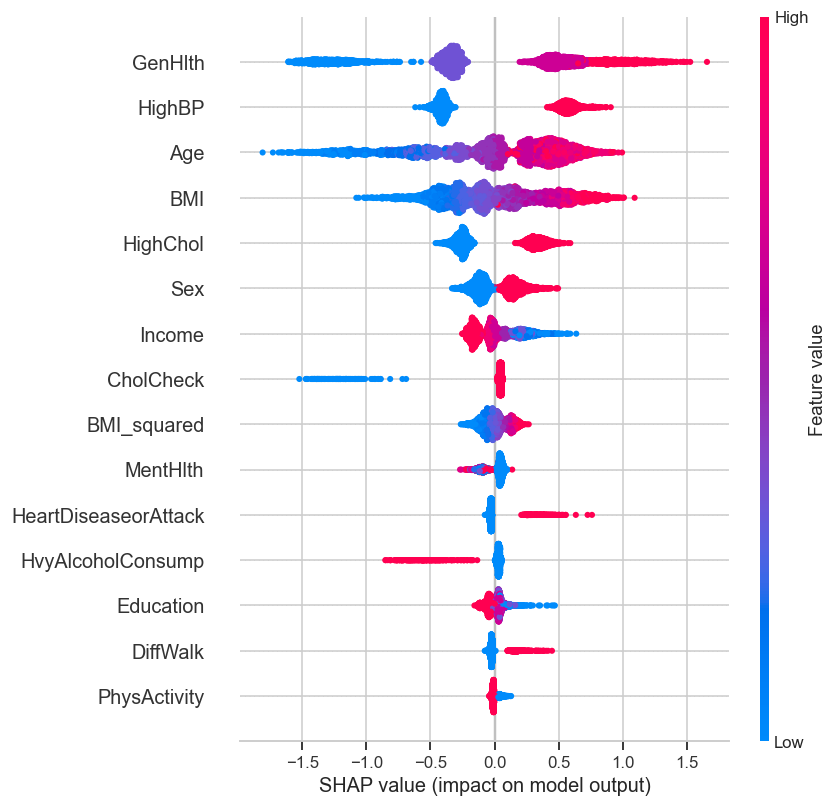

In [14]:
if RUN_SHAP:
    try:
        import shap
        model = primary_pipe.named_steps["model"]      # LightGBM: no scaler in the pipe
        Xs = X_test_pool.sample(min(SHAP_SAMPLE, len(X_test_pool)), random_state=SEED)
        sv = shap.TreeExplainer(model).shap_values(Xs)
        if isinstance(sv, list):           # older shap: [class0, class1]
            sv = sv[1]
        elif getattr(sv, "ndim", 2) == 3:  # newer shap: (n, feat, classes)
            sv = sv[..., 1]
        plt.figure()
        shap.summary_plot(sv, Xs, show=False, max_display=15)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "nb08_shap_summary.png", bbox_inches="tight")
        plt.show()
    except Exception as e:
        print("SHAP skipped:", type(e).__name__, e)
else:
    print("RUN_SHAP=False")

In [15]:
# transparent companion read-out: LogReg odds ratios (coeffs are on the standardised scale,
# so each is the odds multiplier per +1 standard deviation of the feature)
lr = companion_pipe.named_steps["model"]
or_df = (pd.DataFrame({"feature": HEADLINE_POOL, "coef": lr.coef_[0],
                       "odds_ratio_per_SD": np.exp(lr.coef_[0])})
         .sort_values("coef", key=lambda s: s.abs(), ascending=False))
print("LogReg-L2 - odds ratio per +1 standardised unit (top 12 by |coef|):")
print(or_df.head(12).to_string(index=False))
or_df.to_csv(OUTPUT_DIR / "nb08_logreg_odds.csv", index=False)

LogReg-L2 - odds ratio per +1 standardised unit (top 12 by |coef|):
             feature      coef  odds_ratio_per_SD
                 BMI  1.371921           3.942917
         BMI_squared -0.929798           0.394633
             GenHlth  0.566268           1.761680
                 Age  0.405257           1.499688
              HighBP  0.346688           1.414375
            HighChol  0.277013           1.319183
           CholCheck  0.229186           1.257576
   HvyAlcoholConsump -0.164783           0.848077
                 Sex  0.119166           1.126557
              Income -0.115759           0.890690
HeartDiseaseorAttack  0.067270           1.069584
            PhysHlth -0.054788           0.946685


#### Interpretation — interpretability

Both views agree on clinically plausible drivers. The LogReg companion's largest standardised effects are **BMI together with BMI²** (jointly modelling the J-shaped BMI–risk curve), then **general health (GenHlth, OR ≈ 1.76 per SD), age (≈ 1.50), high blood pressure (≈ 1.41) and high cholesterol (≈ 1.32)**, with heavy alcohol use and higher income acting protectively. These line up with the SHAP ranking on the LightGBM, so a transparent linear model and a black-box booster point to the same risk factors — evidence the model relies on genuine clinical signal rather than artefacts. SHAP values are explanatory only and change no decision.

## 11. Performance ceiling and the label-noise argument

The project's red thread: the BRFSS label encodes **diagnosis**, not disease, so undiagnosed cases sit among the negatives. The false-positive profile (11.1) is the primary, assumption-light evidence; an optional sensitivity illustration (11.2) is provided but off by default.

### 11.1 False-positive vs true-positive profiles (NB01 §10.3)

If the model's false positives resemble its true positives on the classic risk factors, many "FPs" may in fact be **undiagnosed** high-risk people — meaning measured precision is a **lower bound** on true quality, not pure model error. This comparison needs no distributional assumptions, so it carries the label-noise argument.

In [16]:
risk_factors = ["HighBP", "HighChol", "BMI", "Age", "GenHlth",
                "DiffWalk", "HeartDiseaseorAttack", "Stroke"]
grp = np.where((pred == 1) & (yte == 1), "TP",
      np.where((pred == 1) & (yte == 0), "FP",
      np.where((pred == 0) & (yte == 1), "FN", "TN")))
prof = (pd.DataFrame(X_test_raw[risk_factors].values, columns=risk_factors)
        .assign(group=grp).groupby("group")[risk_factors].mean().round(3))
prof = prof.loc[[g for g in ["TP", "FP", "FN", "TN"] if g in prof.index]]
print("Mean risk-factor profile by prediction outcome:")
print(prof.to_string())
prof.to_csv(OUTPUT_DIR / "nb08_fp_tp_profile.csv")

# how far does FP sit between TN and TP on each factor? (0 = like TN, 1 = like TP)
if {"TP", "FP", "TN"}.issubset(prof.index):
    pos = ((prof.loc["FP"] - prof.loc["TN"]) /
           (prof.loc["TP"] - prof.loc["TN"]).replace(0, np.nan)).round(2)
    print("\nFP position between TN(0) and TP(1) per factor:")
    print(pos.to_string())

Mean risk-factor profile by prediction outcome:
       HighBP  HighChol     BMI    Age  GenHlth  DiffWalk  HeartDiseaseorAttack  Stroke
group                                                                                  
TP      0.844     0.736  33.015  9.633    3.506     0.434                 0.267   0.113
FP      0.773     0.660  31.110  9.641    3.228     0.329                 0.201   0.081
FN      0.400     0.419  27.631  8.355    2.396     0.098                 0.044   0.026
TN      0.217     0.270  26.465  7.038    2.040     0.054                 0.021   0.012

FP position between TN(0) and TP(1) per factor:
HighBP                  0.89
HighChol                0.84
BMI                     0.71
Age                     1.00
GenHlth                 0.81
DiffWalk                0.72
HeartDiseaseorAttack    0.73
Stroke                  0.68


### 11.2 PU-inspired sensitivity illustration (optional, off by default)

A formal positive-unlabeled estimate (e.g. Elkan-Noto) would try to quantify how many true positives are unlabelled, but it assumes labels are missing **completely at random** (SCAR). That assumption is **not satisfied** here — under-diagnosis correlates with healthcare access (cf. NB05 `healthcare_access_index`) — so we do **not** report it as a valid prevalence estimator. The cell below is a **sensitivity illustration only**, showing directionally how diagnosis-based labels can make observed precision conservative. It is off by default (`RUN_PU = False`); the false-positive profile in §11.1 is the primary evidence. Enable only if you want it as an explicitly-caveated appendix point.

In [17]:
if RUN_PU:
    # PU-INSPIRED SENSITIVITY ILLUSTRATION -- NOT a valid prevalence estimator.
    # The assumptions behind a formal PU estimate (SCAR) are not satisfied here, so the
    # ratio below is illustrative only: it shows how diagnosis-based labels can make
    # observed precision conservative. The FP-vs-TP profile (11.1) is the primary evidence.
    mean_score_pos = float(p_test[yte == 1].mean())     # mean model score on OBSERVED positives
    ratio = prevalence_test / mean_score_pos if mean_score_pos > 0 else float("nan")
    print("PU-inspired sensitivity illustration (NOT a prevalence estimate):")
    print(f"  mean model score on observed positives : {mean_score_pos:.3f}")
    print(f"  illustrative prevalence ratio          : {ratio:.3f}  (observed prev {prevalence_test:.3f})")
    print("  This is not used as a valid prevalence estimator. It is only a sensitivity")
    print("  illustration showing how diagnosis-based labels can make observed precision")
    print("  conservative. The assumptions behind a formal PU estimate are not satisfied here.")
else:
    print("RUN_PU=False  (PU sensitivity illustration skipped; FP-vs-TP profile is the main evidence)")

RUN_PU=False  (PU sensitivity illustration skipped; FP-vs-TP profile is the main evidence)


#### Interpretation — the ceiling

The false-positive profile is the decisive evidence: across **all eight risk factors the FP group sits far closer to the true positives than to the true negatives** — Age 1.00, HighBP 0.89, HighChol 0.84, GenHlth 0.81, DiffWalk 0.72, HeartDisease 0.73, BMI 0.71, Stroke 0.68 (0 = like TN, 1 = like TP). So the model's "false alarms" look like genuine high-risk profiles, not random errors — so some false positives may well be **undiagnosed or simply high-risk individuals**, which means the measured precision is plausibly **conservative** (an underestimate of true quality) under the diagnosis-based label setup. (The PU illustration is left off by default.) Together with NB06's finding that even a different-mechanism model stays ~0.98 error-correlated, this locates the ~0.43 plateau in **label structure and signal, not model choice.**

## 12. Evaluation against the NB01 success criteria

In [18]:
criteria = {
    "1_PR_AUC_above_floor": (f"{pr_test:.4f} vs floor {prevalence_test:.4f} "
                             f"(x{pr_test/prevalence_test:.2f}) -> "
                             + ("PASS" if pr_test > 2 * prevalence_test else "REVIEW")),
    "2_recall_target_>=0.80": (f"{at_thr['recall_sensitivity']} -> "
                               + ("PASS" if at_thr["recall_sensitivity"] >= 0.80 else "BELOW target (discuss)")),
    "3_subgroups": "PARTIAL: Sex comparable; meaningful Age/Income threshold-level disparities flagged (section 9)",
    "4_model_interpretable":  "PASS (SHAP global view + LogReg odds ratios, section 10)",
}
print(json.dumps(criteria, indent=2))

{
  "1_PR_AUC_above_floor": "0.4330 vs floor 0.1393 (x3.11) -> PASS",
  "2_recall_target_>=0.80": "0.7894 -> BELOW target (discuss)",
  "3_subgroups": "PARTIAL: Sex comparable; meaningful Age/Income threshold-level disparities flagged (section 9)",
  "4_model_interpretable": "PASS (SHAP global view + LogReg odds ratios, section 10)"
}


#### Interpretation — verdict

Against the NB01 success criteria: **(1) PR-AUC** = 0.433 vs floor 0.139 (3.1×) — clearly met. **(2) Recall ≥ 0.80** — narrow miss: test recall 0.789, CI just below 0.80 (threshold-transfer drift, reported not patched). **(3) Subgroups** — comparable across Sex, but real disparities across Age and income, flagged for monitoring. **(4) Interpretability** — met (SHAP + LogReg odds agree). The honest overall reading: an interpretable screening model that generalises in line with its CV estimate and operates at a **data-limited plateau** set by diagnosis-based label noise, with one recall-target near-miss and one age/income fairness caveat openly reported rather than hidden.

## 13. Persist outputs and hand off the final model

In [19]:
# --- (a) log the single unbiased test result to the shared ledger + write the eval JSON ---
safe_log_result(RESULTS_CSV, notebook="nb08", model=f"{PRIMARY_NAME}_final_test",
                pr_auc_mean=float(pr_test), pr_auc_std=float("nan"),
                roc_auc_mean=float(roc_test), feature_set=nb07["feature_set"],
                imbalance=nb07["imbalance"], n_folds=0, seed=SEED)

evaluation = {
    "seed": SEED, "primary_model": PRIMARY_NAME, "companion": COMPANION_NAME,
    "feature_set": nb07["feature_set"], "imbalance": nb07["imbalance"],
    "operating_threshold": THRESHOLD,
    "test": {"PR_AUC": round(pr_test, 4), "PR_AUC_CI95": [round(pr_lo, 4), round(pr_hi, 4)],
             "ROC_AUC": round(roc_test, 4), "ROC_AUC_CI95": [round(roc_lo, 4), round(roc_hi, 4)],
             "Brier_raw": round(brier_test, 4), "Brier_isotonic_illustration": round(brier_iso, 4),
             "prevalence": round(prevalence_test, 4)},
    "at_threshold": at_thr,
    "at_threshold_CI95": {"recall": [round(rec_lo, 4), round(rec_hi, 4)],
                          "precision": [round(prc_lo, 4), round(prc_hi, 4)]},
    "oof_reference": OOF_METRICS,
    "oof_to_test_gap_pr_auc": round(pr_test - OOF_METRICS["PR_AUC"], 4),
    "note": ("single unbiased test evaluation; model / threshold / calibration were frozen in NB07; "
             "no decision was taken on the test set in NB08."),
}
with open(OUTPUT_DIR / "nb08_evaluation.json", "w") as f:
    json.dump(evaluation, f, indent=2, default=float)

print("Saved evaluation outputs to", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob("nb08_*")):
    print("  ", p.name)

Saved evaluation outputs to c:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\nb08
   nb08_evaluation.json
   nb08_final_diagnostics.png
   nb08_fp_tp_profile.csv
   nb08_group_thresholds.csv
   nb08_logreg_odds.csv
   nb08_model_comparison.csv
   nb08_shap_summary.png
   nb08_subgroup_Age.csv
   nb08_subgroup_Education.csv
   nb08_subgroup_Income.csv
   nb08_subgroup_Sex.csv


In [20]:
# --- (b) persist the DEPLOYABLE final model (re-use / hand-off / robustness fallback) ---
import joblib
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 1) fitted end-to-end estimator (expects headline_pool-ordered columns)
joblib.dump(primary_pipe, MODELS_DIR / "nb08_final_lightgbm.joblib")

# 2) version-robust fallback: LightGBM native text booster (loadable by any LGBM version)
primary_pipe.named_steps["model"].booster_.save_model(str(MODELS_DIR / "nb08_final_lightgbm.txt"))

# 3) model card: everything needed to serve / reproduce WITHOUT the notebook
model_card = {
    "model": PRIMARY_NAME,
    "trained_on": f"full training set ({len(y_train):,} rows)",
    "raw_features_expected": ALL_FEATURES,                # the 21 raw inputs, in order
    "derived_features": {"BMI_squared": "BMI ** 2"},       # the ONLY engineered column
    "model_input_columns": HEADLINE_POOL,                 # exact order the model expects
    "operating_threshold": THRESHOLD,
    "decision_rule": f"label = 1 if P(diabetes) >= {THRESHOLD:.4f} else 0  (recall-floor screening policy, recall >= {RECALL_TARGET} on OOF)",
    "calibration": "none (raw probabilities; decided in NB07)",
    "test_metrics": evaluation["test"], "at_threshold": at_thr,
    "tuned_params": nb07["tuned"][PRIMARY_NAME]["params"],
    "estimator_defaults": _defaults(PRIMARY_NAME),
    "seed": SEED,
    "versions": {"sklearn": sklearn.__version__, "lightgbm": lightgbm.__version__,
                 "numpy": np.__version__, "pandas": pd.__version__},
}
with open(MODELS_DIR / "nb08_model_card.json", "w") as f:
    json.dump(model_card, f, indent=2, default=float)
print("saved deployable model to", MODELS_DIR)
for p in sorted(MODELS_DIR.glob("nb08_*")):
    print("  ", p.name)

saved deployable model to c:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\models
   nb08_final_lightgbm.joblib
   nb08_final_lightgbm.txt
   nb08_model_card.json


In [21]:
# --- (c) standalone inference helper + round-trip self-test ---
# Raw 21 features in -> probability + label out. No src/ dependency: the only engineered
# column is BMI_squared = BMI**2, so serving needs no build_candidates and no fitted
# preprocessing beyond the saved model.
def predict_from_raw(df_raw21, model=None, threshold=THRESHOLD):
    model = model if model is not None else primary_pipe
    X = df_raw21.copy()
    X["BMI_squared"] = X["BMI"] ** 2
    X = X[HEADLINE_POOL]                       # enforce exact column order
    proba = model.predict_proba(X)[:, 1]
    return pd.DataFrame({"proba": proba, "label": (proba >= threshold).astype(int)},
                        index=df_raw21.index)

# self-test: reload BOTH saved artifacts and confirm they reproduce the in-memory model
reloaded = joblib.load(MODELS_DIR / "nb08_final_lightgbm.joblib")
chk = predict_from_raw(X_test_raw.head(1000), model=reloaded)
assert np.allclose(chk["proba"].values, p_test[:1000], atol=1e-9), "joblib round-trip mismatch"

booster = lightgbm.Booster(model_file=str(MODELS_DIR / "nb08_final_lightgbm.txt"))
Xchk = X_test_raw.head(1000).copy(); Xchk["BMI_squared"] = Xchk["BMI"] ** 2
proba_txt = booster.predict(Xchk[HEADLINE_POOL].values)
assert np.allclose(proba_txt, p_test[:1000], atol=1e-6), "native-booster round-trip mismatch"

print("round-trip OK: joblib and native .txt both reproduce the in-memory predictions")
print(chk.head())

round-trip OK: joblib and native .txt both reproduce the in-memory predictions
       proba  label
5   0.111472      0
9   0.032566      0
10  0.110875      0
12  0.043490      0
14  0.200841      1


#### Interpretation — model hand-off

The model is saved three ways, ordered by robustness: the **joblib** pipeline is the convenient path (`predict_from_raw(df)` on raw 21-feature rows); the **native `.txt` booster** is the version-robust fallback (LightGBM loads its own text format across versions, so it survives a sklearn/joblib version mismatch on another machine); and the **model card** carries the exact feature order, the `BMI_squared = BMI**2` rule, the threshold and the tuned params, so the model can be rebuilt from scratch as a last resort. The round-trip self-test asserts the saved artifacts reproduce the in-memory predictions, so the hand-off is verified, not assumed.

## 14. Summary

1. **One number, honestly earned.** The tuned LightGBM, refit on the full training set, was evaluated **once** on the frozen test split — the only unbiased estimate in the project. PR-AUC, ROC-AUC and Brier are reported with group-aware bootstrap CIs and compared against the OOF reference (≈ 0.436) and the no-skill floor (≈ 0.139).
2. **No new decisions on test.** Model, threshold (recall-floor ≈ 0.138, recall ≥ 0.80) and calibration (none) were all frozen in NB07; NB08 only reports. Pre-registered comparisons (LogReg companion, MLP+LightGBM stack) are shown as context, not as grounds to re-select.
3. **Operating point** applied as frozen; full clinical metric set + confusion matrix with CIs on recall/precision; OOF→full-refit threshold transfer discussed rather than patched.
4. **Calibration** reported raw (decision frozen); isotonic shown only illustratively, fit on train OOF, with the ties caveat noted.
5. **Fairness** across Sex / Age / Income / Education with support counts; the young-age low-recall effect surfaced; an illustrative per-band-threshold Pareto shown as future work.
6. **Interpretability** via SHAP (final model) and LogReg odds ratios (companion), which agree on clinically plausible drivers.
7. **Ceiling / label noise** carried by the assumption-light FP-vs-TP profile; the PU sensitivity illustration is optional and explicitly not a valid estimate.
8. **Deployable model persisted** (joblib + native booster + model card + verified round-trip), so the trained model can be re-used and tested on new data without re-running the pipeline.
9. **Verdict** against the NB01 success criteria. Deployment itself stays out of scope (conceptual, NB00); the persisted model enables hand-off and a future tiered-risk extension (NB01 §10.2), with monitoring of calibration and subgroup recall over time.

The overall reading the project supports: an interpretable diabetes-risk screening model — subgroup-evaluated and with calibration reported as a diagnostic — operating at a **data-limited plateau** set by diagnosis-based label noise and limited self-reported signal, where the honest, leakage-free number is the contribution, not an inflated headline.

## References

- Burrows, N. R., et al. (2017). Incidence of end-stage renal disease attributed to diabetes - United States and Puerto Rico, 2000-2014. *MMWR, 66*(43), 1165-1170.
- Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432.
- van den Goorbergh, R., et al. (2022). The harm of class imbalance corrections for risk prediction models. *JAMIA, 29*(9), 1525-1534.
- Bengio, Y., & Grandvalet, Y. (2004). No unbiased estimator of the variance of K-fold cross-validation. *JMLR, 5*, 1089-1105.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions (SHAP). *NeurIPS 30*.
- Elkan, C., & Noto, K. (2008). Learning classifiers from only positive and unlabeled data. *KDD '08*, 213-220. *(referenced only for the optional, caveated PU sensitivity illustration in 11.2)*